In [10]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx

In [11]:
df = pd.read_csv('full_image_data_feb_25.csv')
books = pd.read_csv('full_book_data_feb_25.csv')

In [12]:
# Assuming 'book_id' is the column to join on
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

In [19]:
# Define the target cks values
target_cks = [
   'CK_Definition of Sphere by Theodosius', 
   'CK_Definition of Sphere by Euclid',  
   'CK_Additions on Definitions of the Sphere',
   'CK_07 Spheres', 
   'CK_08 Spheres', 
    'CK_09 Spheres', 
    'CK_10 Spheres', 
   'CK_11 Spheres', 
   'CK_12 Spheres',
    'CK_Right and Oblique Sphere', 
      'CK_Structure of the Sublunar World',
   'CK_Qualities of the Aristotelian Elements',
    'CK_Symbols of the Elements',
    'CK_Relation Between the Spheres of Water and Earth',
       'CK_Daily Rotation of the Firmament',
    # 'CK_Earth and Cosmos',
    'CK_Motion of the Eighth Sphere',
    'CK_Complete Motion of the Eighth Sphere (Thebit)',
    'CK_Complete Motion of the Eighth Sphere',
    'CK_Motion of the Eighth Sphere at Boundary',
    'CK_Motion of the Eighth Sphere at  Boundary',
      'CK_Sphericity of the Heavens',
    'CK_Isoperimetry',
    'CK_Refraction',
    'CK_Apparent Size of Stars',
     'CK_Sphericity of the Earth',
    'CK_Visibility of Stars from Varied Locations',
    'CK_Rising and Setting Times at Different Locations',
     'CK_Sphericity of the Water Element',
   # 'CK_Relation Between the Spheres of Water and Earth',
      'CK_Negligible Dimensions of the Earth',
    'CK_Central Intersection of Eclipses',
    'CK_Visibility of Half of the Sky from the Central Earth', 
    'CK_Centrality of Earth',
      'CK_Measurements of the Earth',
    'CK_Correlation Between Distances on Earth and Locations of Stars', 
    'CK_Circle and Diameter Rule', 
    'CK_Assumed Parallellity of the Sun Rays',
    'CK_Planets Sizes and Distances'
]

In [20]:
#filtering the df to get the images of the target cks with all their data + printing counts
#(this is why only filter is not enough: we need all the cks that are in other rows with double images values)

# Step 1: Filter the DataFrame for rows where 'cks' is in the target_cks list
filtered_df_target_cks = df[df['cks'].isin(target_cks)]

# Step 2: Get the unique 'images' values associated with the target cks
images_with_target_cks = filtered_df_target_cks['images'].unique()

# Step 3: Filter the original DataFrame to include all rows that have these images
filtered_df = df[df['images'].isin(images_with_target_cks)]

# filtered_df

In [21]:
unique_counts = pd.concat([
    df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('df'),
    filtered_df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('filtered_df')
], axis=1)

print(unique_counts)

                 df  filtered_df
images        20540         5161
cluster_name   3563          686
cks             168           58
place            42           41
printer         166          160
publisher       155          149


Number of Unique Books per CK Group, All Books, and Filtered Books:
               CK_Definition of Sphere by Theodosius  \
year_interval                                          
1470-1489                                        5.0   
1490-1509                                       25.0   
1510-1529                                       15.0   
1530-1549                                       25.0   
1550-1569                                       30.0   
1570-1589                                       25.0   
1590-1609                                       15.0   
1610-1629                                        4.0   
1630-1650                                        0.0   

               CK_Definition of Sphere by Euclid  \
year_interval                                      
1470-1489                                      5   
1490-1509                                     31   
1510-1529                                     22   
1530-1549                                     35   
155

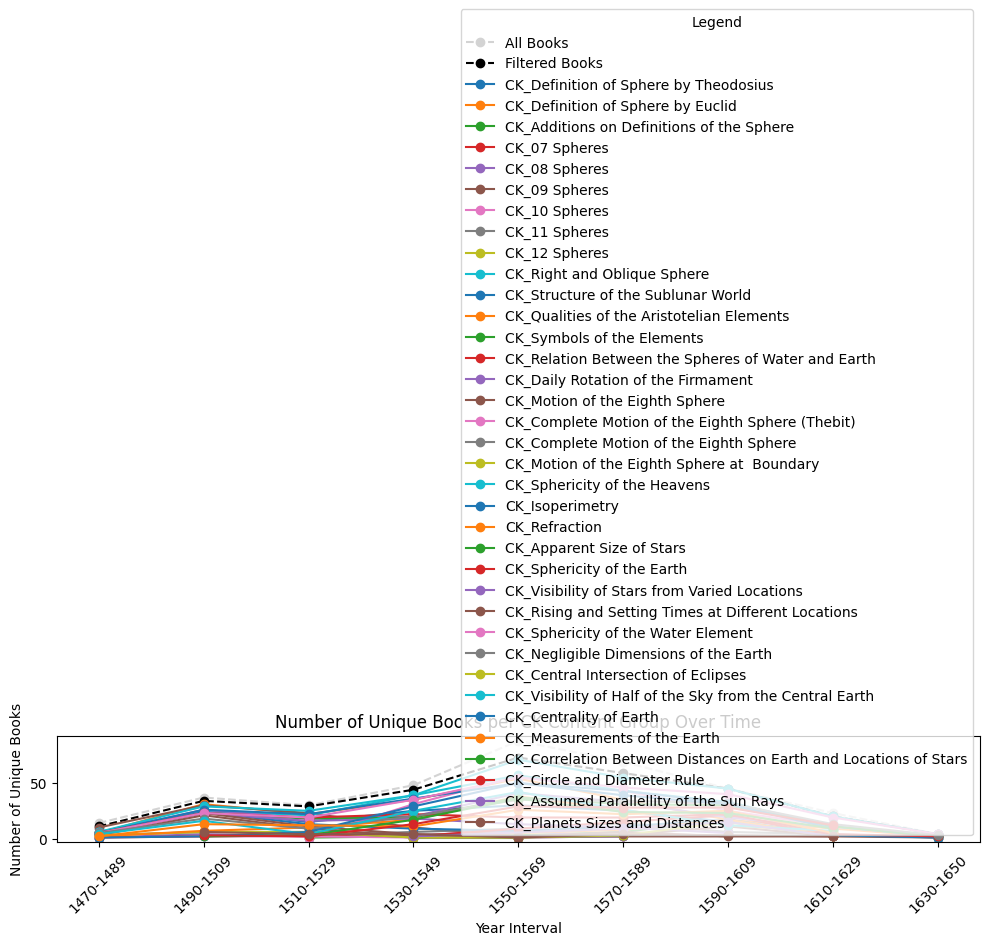

In [22]:

# ✅ 1. Total books per year_interval (from full books df)
all_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# ✅ 2. Total books per year_interval (from filtered_df)
filtered_books_count = filtered_df.groupby('year_interval', observed=False)['book'].nunique()

# ✅ Use the full timeline from all_books_count
intervals = all_books_count.index.astype(str)

# ✅ 3. Book counts per CK from filtered_df
book_counts = {
    keyword: (
        filtered_df[filtered_df['cks'] == keyword]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# ✅ 4. Create unified DataFrame
book_counts_df = pd.DataFrame(book_counts).reindex(all_books_count.index).fillna(0)
book_counts_df['All Books'] = all_books_count
book_counts_df['Filtered Books'] = filtered_books_count.reindex(all_books_count.index).fillna(0)

# ✅ 5. Print the summary table
print("Number of Unique Books per CK Group, All Books, and Filtered Books:")
print(book_counts_df)

# ✅ 6. Plotting
plt.figure(figsize=(10, 6))

# Plot total number of books (full dataset)
plt.plot(intervals, book_counts_df['All Books'].values, label='All Books', marker='o', color='lightgrey', linestyle='--')

# Plot number of filtered books
plt.plot(intervals, book_counts_df['Filtered Books'].values, label='Filtered Books', marker='o', color='black', linestyle='--')

# Plot each CK content group (only where values are non-zero)
for keyword in target_cks:
    values = book_counts_df[keyword].values
    non_zero_intervals = [intervals[i] for i, val in enumerate(values) if val > 0]
    non_zero_values = [val for val in values if val > 0]

    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# ✅ 7. Final touches
plt.title('Number of Unique Books per CK Content Group Over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='Legend')
plt.tight_layout()

# ✅ 8. Save the figure
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/chapter_1.png', dpi=300)

# ✅ 9. Show the plot
plt.show()


Number of Unique Books (All vs Filtered) per Year Interval:
               All Books  Filtered Books
year_interval                           
1470-1489             14              11
1490-1509             37              34
1510-1529             30              29
1530-1549             48              44
1550-1569             88              73
1570-1589             69              59
1590-1609             45              45
1610-1629             23              20
1630-1650              4               4


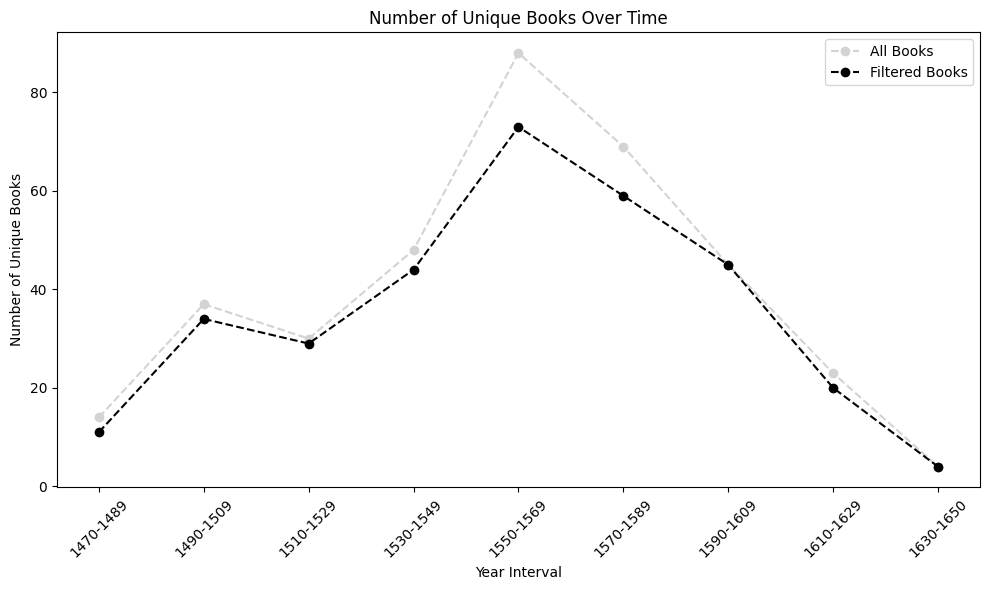

In [23]:
# ✅ 1. Total books per year_interval (from full books df)
all_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# ✅ 2. Total books per year_interval (from filtered_df)
filtered_books_count = filtered_df.groupby('year_interval', observed=False)['book'].nunique()

# ✅ Use the full timeline from all_books_count
intervals = all_books_count.index.astype(str)

# ✅ 3. Combine into single DataFrame
book_counts_df = pd.DataFrame({
    'All Books': all_books_count,
    'Filtered Books': filtered_books_count.reindex(all_books_count.index).fillna(0)
})

# ✅ 4. Print the summary table
print("Number of Unique Books (All vs Filtered) per Year Interval:")
print(book_counts_df)

# ✅ 5. Plotting
plt.figure(figsize=(10, 6))

# Plot total books (all books)
plt.plot(
    intervals,
    book_counts_df['All Books'].values,
    label='All Books',
    marker='o',
    color='lightgrey',
    linestyle='--'
)

# Plot filtered books
plt.plot(
    intervals,
    book_counts_df['Filtered Books'].values,
    label='Filtered Books',
    marker='o',
    color='black',
    linestyle='--'
)

# ✅ 6. Final touches
plt.title('Number of Unique Books Over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# ✅ 7. Save the figure
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/chapter_1_filtered_vs_all.png', dpi=300)

# ✅ 8. Show the plot
plt.show()


In [27]:

# === Assumes this is already defined earlier ===
# target_cks = ['CK_Sphericity of the Water Element',
#               'CK_Relation Between the Spheres of Water and Earth'
#               ]

# === Step 1: Visual tags ===
defined_columns = [
    '3D', 
    'human figures', 
    'simple',
    # 'color', 
    'diagram', 
    'decoration', 
    'material globus',
    # 'multiple perspectives'
        ]

# === Step 2: Build edge list ===
edges = []
places = visual_df['place'].dropna().unique().tolist()

for place in places:
    place_data = visual_df[visual_df['place'] == place]

    # Add CKs only if in target_cks
    for cks in target_cks:
        if (place_data['cks'] == cks).any():
            edges.append((place, cks))

    # Add visual tag edges
    for tag in visual_tags:
        if (place_data[tag] == 'yes').any():
            edges.append((place, tag))

# Optional: inspect edge structure
# edges_df = pd.DataFrame(edges, columns=['place', 'tag'])
# print(edges_df)

# === Step 3: Unique node sets ===
places = list(set(edge[0] for edge in edges))
tags = list(set(edge[1] for edge in edges))

# === Step 4: Color by place category ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
existing_categories = visual_df['place_category'].dropna().unique()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]

color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {
    cat: color for cat, color in zip(ordered_present_categories, color_palette)
}

place_color_map = {}
for place in places:
    cat_series = visual_df[visual_df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# === Step 5: Build the graph ===
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)
G.add_nodes_from(tags, bipartite=1)
G.add_edges_from(edges)

# === Step 6: Assign node colors ===
node_colors = [
    place_color_map[node] if node in places else 'lightgray'
    for node in G.nodes()
]

# === Step 7: Draw ===
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# === Step 8: Legend ===
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='lightgray', label='Tag (CK or Visual)'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)
plt.title("Bipartite Graph: Places and Target CKs / Visual Tags")

# === Step 9: Save or show ===
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/chapter_1_network.png', dpi=300)
plt.show()


NameError: name 'visual_df' is not defined